# Estimateurs de covariance
**Question de recherche.** Quel estimateur de la matrice de covariance Σ est le plus pertinent
pour l'optimisation de portefeuille sur le S&P 500, évalué **exclusivement hors échantillon**
selon **deux axes** :
1. **Statistique / prédictif** 
   est-il proche de la covariance réalisée (RMSE/MAE/Frobenius), bien conditionné et stable ?
2. **Portefeuille** les allocations construites sur ce Σ sont-elles meilleures en risque
   réalisé, Sharpe net, drawdown, turnover ?

**Cadre expérimental.** Une seule variable change à la fois (`dataclasses.replace`), mêmes
données / fenêtres / coûts. 


## 1. Données

In [1]:
import sys, time, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "..")
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import replace

import portfolio_lab as pl
from portfolio_lab.backtest import WalkForwardBacktestConfig, plot_backtest_nav

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# ------------------------------------------------------------------ #
#  USE_SYNTHETIC=True : tourne sans réseau (sandbox/CI).             #
#  En production, laissez False (vraies données yfinance).          #
# ------------------------------------------------------------------ #
USE_SYNTHETIC = False
START, END = "2012-01-01", "2025-12-31"

In [2]:
# --- Univers CONFIGURABLE (Option 1 : complet ; Option 2 : sous-échantillon) ---
# Décommentez le sélecteur voulu. Tout le reste du notebook est inchangé.
constituents = pl.get_sp500_constituents()

SELECTOR = pl.StratifiedBySector(n_total=80, seed=42)   # diversifié par secteur (défaut)
# SELECTOR = pl.AllUniverse()                            # Option 1 : S&P 500 complet (~500, lent)
# SELECTOR = pl.TopN(40)                                 # N premiers (ALPHABÉTIQUE)
# SELECTOR = pl.RandomN(50, seed=42)                     # aléatoire reproductible

universe = SELECTOR.select(constituents)
if USE_SYNTHETIC:
    prices = pl.make_synthetic_prices(constituents.loc[universe], START, END)
else:
    prices = pl.clean_prices(pl.download_prices(universe, START, END))

returns = pl.compute_returns(prices, "simple")
print(f"Univers : {prices.shape[1]} actifs | {prices.shape[0]} obs "
      f"({prices.index[0].date()} -> {prices.index[-1].date()})")

[OK] 503 composants récupérés depuis Wikipédia.


Univers : 70 actifs | 3450 obs (2012-04-12 -> 2025-12-30)


In [3]:
# Backtest walk-forward — IDENTIQUE pour toutes les variantes (variables contrôlées).
BT_CFG = WalkForwardBacktestConfig(
    estimation_window=252,      # 1 an pour estimer mu, Sigma
    holding_period=21,          # rebalancement ~mensuel
    transaction_cost_bps=10.0,  # coûts sur le turnover (stratégie ET benchmark 1/N)
    long_only=True,
    frequency="daily",
    risk_free_annual=0.04,      # Sharpe NET du taux sans risque
)
PPY = pl.periods_per_year(BT_CFG.frequency)
WINDOW, STEP = BT_CFG.estimation_window, BT_CFG.holding_period

In [4]:
# Les 7 estimateurs de covariance comparés 
estimators = {
    "Rolling-120":      pl.RollingCovariance(window=120),
    "EWMA λ=0.94":      pl.EWMACovariance(lam=0.94),
    "EWMA λ=0.97":      pl.EWMACovariance(lam=0.97),
    "IEWMA":            pl.IEWMACovariance(vol_halflife=125, corr_halflife=21),
    "Ledoit-Wolf":      pl.LedoitWolfCovariance(),
    "OAS":              pl.OASCovariance(),
    "Corr. constante":  pl.ConstantCorrelationCovariance(),
    "Empirique":        pl.EmpiricalCovariance(),
}
MEAN_EST = pl.EWMAMean(lam=0.9)
# MEAN_EST = pl.SampleMean()  
print("Estimateurs Σ :")
for name, est in estimators.items():
    print(f"  {name}")

Estimateurs Σ :
  Rolling-120
  EWMA λ=0.94
  EWMA λ=0.97
  IEWMA
  Ledoit-Wolf
  OAS
  Corr. constante
  Empirique


## 2. Evaluation statistique (hors échantillon)

In [5]:
# Résumé statistique (moyenne sur toutes les fenêtres OOS) par estimateur.
stat = pl.cov_eval_summary(returns, estimators, window=WINDOW, step=STEP, demean=False)
stat["stabilité"] = {name: pl.temporal_stability(returns, est, window=WINDOW, step=STEP)
                     for name, est in estimators.items()}
cols = ["loglik", "rmse_cov", "mae_cov", "frobenius", "vol_abs_err",
        "condition_number", "stabilité"]
display(stat[cols].round({"loglik": 2, "rmse_cov": 6, "mae_cov": 6, "frobenius": 6,
                          "vol_abs_err": 5, "condition_number": 1, "stabilité": 4}))

,loglik,rmse_cov,mae_cov,frobenius,vol_abs_err,condition_number,stabilité
Rolling-120,140.1100,0.0002,0.0001,0.0123,0.0037,2180.0000,0.3062
EWMA λ=0.94,-562.0800,0.0002,0.0001,0.0126,0.0035,27384.0000,0.9978
EWMA λ=0.97,103.0000,0.0002,0.0001,0.0118,0.0034,3136.8000,0.6343
IEWMA,60.3500,0.0002,0.0001,0.0118,0.0035,3707.6000,0.4487
Ledoit-Wolf,197.1600,0.0002,0.0001,0.0121,0.0039,236.5000,0.1565
OAS,194.8100,0.0002,0.0001,0.0122,0.0040,349.9000,0.1593
Corr. constante,193.7100,0.0002,0.0001,0.0124,0.0040,122.4000,0.1400
Empirique,188.3500,0.0002,0.0001,0.0123,0.0040,798.4000,0.1573


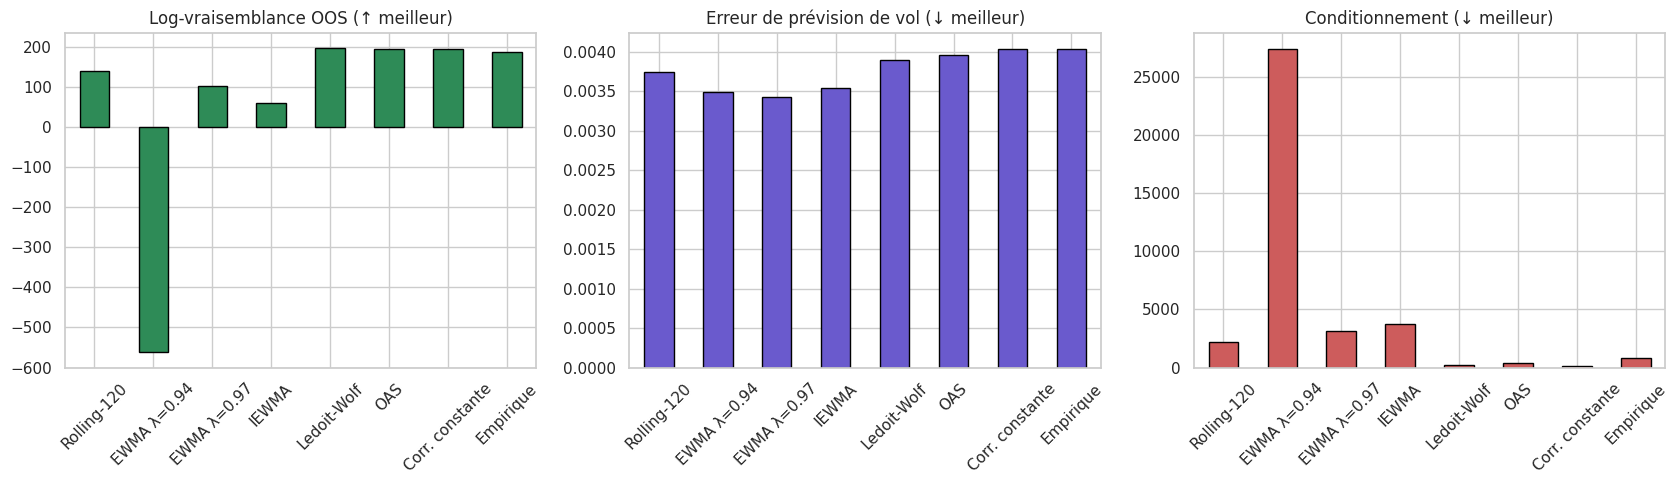

In [6]:
# Lecture visuelle : log-vraisemblance (haut = meilleur prédicteur) et conditionnement (bas = mieux).
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
stat["loglik"].plot(kind="bar", ax=axes[0], color="seagreen", edgecolor="black")
axes[0].set_title("Log-vraisemblance OOS (↑ meilleur)")
stat["vol_abs_err"].plot(kind="bar", ax=axes[1], color="slateblue", edgecolor="black")
axes[1].set_title("Erreur de prévision de vol (↓ meilleur)")
stat["condition_number"].plot(kind="bar", ax=axes[2], color="indianred", edgecolor="black")
axes[2].set_title("Conditionnement (↓ meilleur)")
for a in axes: a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

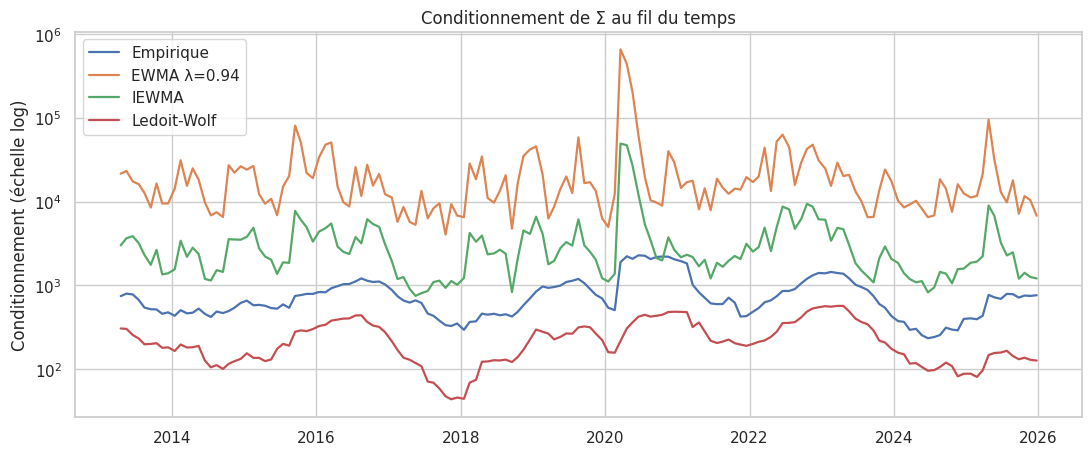

In [7]:
# Conditionnement DANS LE TEMPS (stabilité numérique) — quelques estimateurs.
fig, ax = plt.subplots(figsize=(13, 5))
for name in ["Empirique", "EWMA λ=0.94", "IEWMA", "Ledoit-Wolf"]:
    df = pl.rolling_cov_eval(returns, estimators[name], window=WINDOW, step=STEP)
    ax.plot(df.index, df["condition_number"], label=name, lw=1.6)
ax.set_yscale("log"); ax.set_ylabel("Conditionnement (échelle log)")
ax.set_title("Conditionnement de Σ au fil du temps"); ax.legend(); plt.show()

### Comportement en **crise** vs **hors-crise**

On sépare les fenêtres par quartile de volatilité réalisée (crise = quart le plus volatil) et on
compare conditionnement et erreurs. Attendu : les estimateurs dynamiques (EWMA/IEWMA) résistent
mieux en stress sur le plan prédictif, mais leur conditionnement se dégrade.

In [8]:
regime_rows = {}
for name, est in estimators.items():
    df = pl.rolling_cov_eval(returns, est, window=WINDOW, step=STEP)
    rs = pl.regime_split(df)
    regime_rows[name] = {
        "loglik (calme)": rs.loc["hors_crise", "loglik"],
        "loglik (crise)": rs.loc["crise", "loglik"],
        "cond (calme)":   rs.loc["hors_crise", "condition_number"],
        "cond (crise)":   rs.loc["crise", "condition_number"],
        "vol_err (crise)": rs.loc["crise", "vol_abs_err"],
    }
display(pd.DataFrame(regime_rows).T.round({"loglik (calme)": 2, "loglik (crise)": 2,
        "cond (calme)": 1, "cond (crise)": 1, "vol_err (crise)": 5}))

,loglik (calme),loglik (crise),cond (calme),cond (crise),vol_err (crise)
Rolling-120,158.2200,87.1600,1841.1000,3170.5000,0.0072
EWMA λ=0.94,-429.6300,-949.2200,17271.6000,56943.5000,0.0069
EWMA λ=0.97,128.7900,27.6300,2284.5000,5628.1000,0.0066
IEWMA,117.9600,-108.0400,2662.2000,6763.4000,0.0066
Ledoit-Wolf,204.9500,174.4000,218.0000,290.6000,0.0075
OAS,203.9300,168.1600,301.6000,491.0000,0.0075
Corr. constante,201.4100,171.1900,116.8000,138.8000,0.0073
Empirique,199.1300,156.8300,713.6000,1046.3000,0.0073


## 3. Benchmark portefeuille

### a. On fixe l'objectif min_variance et on fait varier l'estimateur de Σ
y est maximal. μ = SampleMean, optimiseur CVXPY, `w_max=10%`, mêmes fenêtres et coûts.

In [9]:
base_mv = pl.ExperimentConfig(
    universe=SELECTOR, frequency=BT_CFG.frequency, return_mode="simple",
    mean_estimator=MEAN_EST, objective="min_variance",
    optimizer=pl.CVXPYOptimizer(), long_only=True, w_max=0.10, risk_free_annual=0.04,
)
variants_mv = {name: replace(base_mv, cov_estimator=est) for name, est in estimators.items()}

t0 = time.time()
res_mv = pl.run_oos_benchmark(prices, variants_mv, backtest_config=BT_CFG)
print(f"7 backtests min_variance en {time.time()-t0:.1f}s")

cols_perf = ["Total return (%)", "CAGR (%)", "Vol annualized (%)", "Sharpe",
             "Max drawdown (%)", "Tracking error (%)", "Average turnover", "Fallback count"]
m_mv = pl.metrics_table(res_mv)
display(m_mv[cols_perf].round(3))

7 backtests min_variance en 17.6s


,Total return (%),CAGR (%),Vol annualized (%),Sharpe,Max drawdown (%),Tracking error (%),Average turnover,Fallback count
Rolling-120,359.0620,12.7640,13.9820,0.6270,-37.5090,9.6620,0.0220,0.0000
EWMA λ=0.94,444.8220,14.2970,14.0890,0.7310,-38.4460,9.4490,0.0470,0.0000
EWMA λ=0.97,418.8650,13.8580,13.8160,0.7140,-36.1940,9.6340,0.0330,0.0000
IEWMA,363.7300,12.8540,14.0460,0.6300,-39.5860,9.2960,0.0350,0.0000
Ledoit-Wolf,350.5680,12.5980,14.0500,0.6120,-40.2070,9.5400,0.0120,0.0000
OAS,350.2440,12.5920,14.0670,0.6110,-40.3470,9.5940,0.0120,0.0000
Corr. constante,310.1330,11.7670,14.8390,0.5230,-30.1420,11.2700,0.0080,0.0000
Empirique,347.5330,12.5380,14.0790,0.6060,-40.2780,9.6740,0.0120,0.0000


In [10]:
# Métriques de queue + stabilité des poids (robustesse).
display(pl.tail_metrics_table(res_mv, periods_per_year_=PPY, rf_annual=0.04).round(3))
display(pl.weight_stability(res_mv).round(4))

,Sortino,Calmar,VaR 5% (%),CVaR 5% (%),Skew,Kurtosis
Rolling-120,0.5770,0.3400,1.1690,2.0120,-1.6290,32.1390
EWMA λ=0.94,0.6640,0.3720,1.1710,2.0220,-1.7710,30.8430
EWMA λ=0.97,0.6570,0.3830,1.1330,1.9640,-1.6090,31.8450
IEWMA,0.5800,0.3250,1.1620,2.0060,-1.7610,31.9160
Ledoit-Wolf,0.5590,0.3130,1.1350,2.0140,-1.7320,33.3010
OAS,0.5590,0.3120,1.1330,2.0160,-1.7340,33.3400
Corr. constante,0.4970,0.3900,1.2230,2.1170,-0.5190,26.6400
Empirique,0.5540,0.3110,1.1310,2.0160,-1.7370,33.5310


,turnover moyen,Herfindahl moyen,N actifs effectifs
Rolling-120,0.4603,0.0728,13.7288
EWMA λ=0.94,0.9795,0.0771,12.9667
EWMA λ=0.97,0.6869,0.0741,13.4878
IEWMA,0.7348,0.0735,13.5973
Ledoit-Wolf,0.2440,0.0663,15.0926
OAS,0.2465,0.0684,14.6228
Corr. constante,0.1703,0.0728,13.7366
Empirique,0.2527,0.0721,13.8608


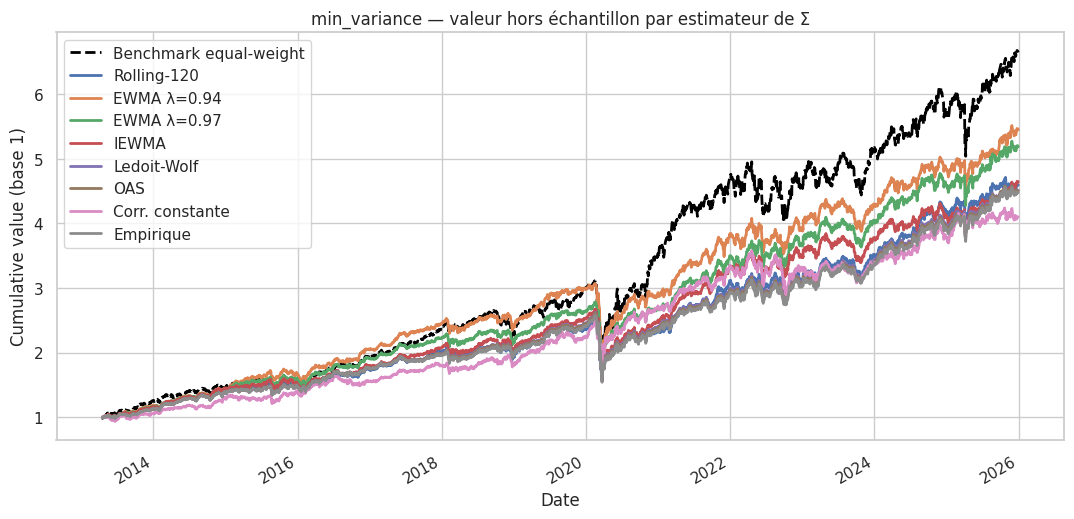

In [11]:
# Courbes de valeur OOS (base 1) + benchmark 1/N (coûts inclus des deux côtés).
fig, ax = plt.subplots(figsize=(13, 6))
plot_backtest_nav(res_mv, ax=ax)
ax.set_title("min_variance — valeur hors échantillon par estimateur de Σ")
plt.show()

### b. Max_sharpe 
Si la dispersion du Sharpe entre estimateurs **rétrécit** vs `min_variance`, c'est que l'erreur
sur μ domine — améliorer Σ aide surtout là où μ n'intervient pas.

In [12]:
variants_ms = {name: replace(cfg, objective="max_sharpe") for name, cfg in variants_mv.items()}
res_ms = pl.run_oos_benchmark(prices, variants_ms, backtest_config=BT_CFG)
m_ms = pl.metrics_table(res_ms)
display(m_ms[["CAGR (%)", "Vol annualized (%)", "Sharpe", "Max drawdown (%)",
             "Average turnover", "Fallback count"]].round(3))
print(f"Dispersion Sharpe min_variance : {m_mv['Sharpe'].max()-m_mv['Sharpe'].min():.3f}")
print(f"Dispersion Sharpe max_sharpe   : {m_ms['Sharpe'].max()-m_ms['Sharpe'].min():.3f}")

[WARN] fallback equal-weight for Rolling-120: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


[WARN] fallback equal-weight for EWMA λ=0.94: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


[WARN] fallback equal-weight for EWMA λ=0.97: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


[WARN] fallback equal-weight for IEWMA: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


[WARN] fallback equal-weight for Ledoit-Wolf: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


[WARN] fallback equal-weight for OAS: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


[WARN] fallback equal-weight for Corr. constante: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


[WARN] fallback equal-weight for Empirique: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


,CAGR (%),Vol annualized (%),Sharpe,Max drawdown (%),Average turnover,Fallback count
Rolling-120,16.6190,16.9130,0.7460,-34.3570,0.0720,1.0000
EWMA λ=0.94,15.7350,16.7720,0.7000,-37.5700,0.0710,1.0000
EWMA λ=0.97,15.9190,16.8270,0.7080,-36.3090,0.0720,1.0000
IEWMA,14.5250,17.0660,0.6170,-39.2860,0.0720,1.0000
Ledoit-Wolf,14.7300,17.3850,0.6170,-37.0250,0.0730,1.0000
OAS,14.7200,17.3620,0.6170,-37.0480,0.0730,1.0000
Corr. constante,13.9290,18.0870,0.5490,-34.5340,0.0780,1.0000
Empirique,14.7100,17.3360,0.6180,-37.1040,0.0730,1.0000


Dispersion Sharpe min_variance : 0.207
Dispersion Sharpe max_sharpe   : 0.197


In [13]:
# COMPARATIF DES COVARIAANCES POUR CHAQUE PORTFOLIO
base_pf0 = replace(base_mv, objective="max_sharpe", optimizer=pl.CVXPYOptimizer())

In [14]:
# COMPARATIFS DES COVARIANCES POU EQUIPONDERE 1/N
base_pf = replace(base_pf0, optimizer=pl.EqualWeightOptimizer())
portfolios = {
    "Ledoit-Wolf":      replace(base_pf, cov_estimator=pl.LedoitWolfCovariance()),
    "EWMA":         replace(base_pf, cov_estimator=pl.EWMACovariance(lam=0.94)),
    "Empirique":        replace(base_pf, cov_estimator=pl.EmpiricalCovariance()),
    "Oas":              replace(base_pf, cov_estimator=pl.OASCovariance()),
    "Cor":              replace(base_pf, cov_estimator=pl.ConstantCorrelationCovariance()),
    "IEWMA":            replace(base_pf, cov_estimator=pl.IEWMACovariance(vol_halflife=125, corr_halflife=21)),
    "Rolling":          replace(base_pf, cov_estimator=pl.RollingCovariance(window=120)),
}
res_pf = pl.run_oos_benchmark(prices, portfolios, backtest_config=BT_CFG)
m_pf = pl.metrics_table(res_pf)
display(m_pf[cols_perf].round(3))
display(pl.tail_metrics_table(res_pf, periods_per_year_=PPY, rf_annual=0.04).round(3))

,Total return (%),CAGR (%),Vol annualized (%),Sharpe,Max drawdown (%),Tracking error (%),Average turnover,Fallback count
Ledoit-Wolf,564.4500,16.0990,17.6300,0.6860,-40.5090,0.0000,0.0000,0.0000
EWMA,564.4500,16.0990,17.6300,0.6860,-40.5090,0.0000,0.0000,0.0000
Empirique,564.4500,16.0990,17.6300,0.6860,-40.5090,0.0000,0.0000,0.0000
Oas,564.4500,16.0990,17.6300,0.6860,-40.5090,0.0000,0.0000,0.0000
Cor,564.4500,16.0990,17.6300,0.6860,-40.5090,0.0000,0.0000,0.0000
IEWMA,564.4500,16.0990,17.6300,0.6860,-40.5090,0.0000,0.0000,0.0000
Rolling,564.4500,16.0990,17.6300,0.6860,-40.5090,0.0000,0.0000,0.0000


,Sortino,Calmar,VaR 5% (%),CVaR 5% (%),Skew,Kurtosis
Ledoit-Wolf,0.6470,0.3970,1.5500,2.5960,-0.6610,21.3030
EWMA,0.6470,0.3970,1.5500,2.5960,-0.6610,21.3030
Empirique,0.6470,0.3970,1.5500,2.5960,-0.6610,21.3030
Oas,0.6470,0.3970,1.5500,2.5960,-0.6610,21.3030
Cor,0.6470,0.3970,1.5500,2.5960,-0.6610,21.3030
IEWMA,0.6470,0.3970,1.5500,2.5960,-0.6610,21.3030
Rolling,0.6470,0.3970,1.5500,2.5960,-0.6610,21.3030


In [15]:
# COMPARAISONS SUR RISK PARITY
base_pf = replace(base_pf0, optimizer=pl.RiskParityOptimizer())
portfolios = {
    "Ledoit-Wolf":      replace(base_pf, cov_estimator=pl.LedoitWolfCovariance()),
    "EWMA":         replace(base_pf, cov_estimator=pl.EWMACovariance(lam=0.94)),
    "Empirique":        replace(base_pf, cov_estimator=pl.EmpiricalCovariance()),
    "Oas":              replace(base_pf, cov_estimator=pl.OASCovariance()),
    "Cor":              replace(base_pf, cov_estimator=pl.ConstantCorrelationCovariance()),
    "IEWMA":            replace(base_pf, cov_estimator=pl.IEWMACovariance(vol_halflife=125, corr_halflife=21)),
    "Rolling":          replace(base_pf, cov_estimator=pl.RollingCovariance(window=120)),
}
res_pf = pl.run_oos_benchmark(prices, portfolios, backtest_config=BT_CFG)
m_pf = pl.metrics_table(res_pf)
display(m_pf[cols_perf].round(3))
display(pl.tail_metrics_table(res_pf, periods_per_year_=PPY, rf_annual=0.04).round(3))

,Total return (%),CAGR (%),Vol annualized (%),Sharpe,Max drawdown (%),Tracking error (%),Average turnover,Fallback count
Ledoit-Wolf,497.4450,15.1310,16.0810,0.6920,-37.6580,2.9160,0.0020,0.0000
EWMA,490.2630,15.0210,15.7480,0.7000,-38.0120,3.6000,0.0140,0.0000
Empirique,495.9590,15.1080,16.0600,0.6920,-37.6180,2.9610,0.0020,0.0000
Oas,496.8180,15.1210,16.0700,0.6920,-37.6500,2.9380,0.0020,0.0000
Cor,472.1710,14.7390,16.5300,0.6500,-38.7580,2.2100,0.0020,0.0000
IEWMA,487.4760,14.9780,15.9250,0.6890,-37.9020,3.2850,0.0080,0.0000
Rolling,490.9120,15.0310,15.9130,0.6930,-37.4520,3.2450,0.0040,0.0000


,Sortino,Calmar,VaR 5% (%),CVaR 5% (%),Skew,Kurtosis
Ledoit-Wolf,0.6480,0.4020,1.4250,2.3650,-0.8330,24.1250
EWMA,0.6480,0.3950,1.3900,2.3280,-0.8980,24.2520
Empirique,0.6470,0.4020,1.4210,2.3620,-0.8350,24.1670
Oas,0.6470,0.4020,1.4230,2.3640,-0.8360,24.1380
Cor,0.6110,0.3800,1.4620,2.4350,-0.7580,23.3710
IEWMA,0.6440,0.3950,1.3910,2.3420,-0.8500,24.7130
Rolling,0.6460,0.4010,1.3880,2.3420,-0.8480,24.4410


In [16]:
# COMPAISON SUR MAX DIVERSIFICATION
base_pf = replace(base_pf0, optimizer=pl.MaxDiversificationOptimizer())
portfolios = {
    "Ledoit-Wolf":      replace(base_pf, cov_estimator=pl.LedoitWolfCovariance()),
    "EWMA":         replace(base_pf, cov_estimator=pl.EWMACovariance(lam=0.94)),
    "Empirique":        replace(base_pf, cov_estimator=pl.EmpiricalCovariance()),
    "Oas":              replace(base_pf, cov_estimator=pl.OASCovariance()),
    "Cor":              replace(base_pf, cov_estimator=pl.ConstantCorrelationCovariance()),
    "IEWMA":            replace(base_pf, cov_estimator=pl.IEWMACovariance(vol_halflife=125, corr_halflife=21)),
    "Rolling":          replace(base_pf, cov_estimator=pl.RollingCovariance(window=120)),
}
res_pf = pl.run_oos_benchmark(prices, portfolios, backtest_config=BT_CFG)
m_pf = pl.metrics_table(res_pf)
display(m_pf[cols_perf].round(3))
display(pl.tail_metrics_table(res_pf, periods_per_year_=PPY, rf_annual=0.04).round(3))

,Total return (%),CAGR (%),Vol annualized (%),Sharpe,Max drawdown (%),Tracking error (%),Average turnover,Fallback count
Ledoit-Wolf,777.7730,18.6750,15.3600,0.9550,-40.2650,8.0750,0.0130,0.0000
EWMA,695.1810,17.7550,15.6940,0.8760,-41.2610,7.9890,0.0520,0.0000
Empirique,842.5910,19.3440,15.5810,0.9850,-40.1320,8.1730,0.0140,0.0000
Oas,810.4670,19.0180,15.4690,0.9710,-40.0540,8.1190,0.0130,0.0000
Cor,469.1640,14.6910,16.5220,0.6470,-38.7090,2.2240,0.0020,0.0000
IEWMA,801.7630,18.9280,15.6780,0.9520,-41.1200,7.8750,0.0400,0.0000
Rolling,723.1350,18.0760,15.5540,0.9050,-40.3810,8.1010,0.0240,0.0000


,Sortino,Calmar,VaR 5% (%),CVaR 5% (%),Skew,Kurtosis
Ledoit-Wolf,0.8690,0.4640,1.2790,2.2470,-1.5060,25.6960
EWMA,0.8140,0.4300,1.3410,2.2660,-1.2500,26.4810
Empirique,0.9000,0.4820,1.3030,2.2760,-1.4310,24.7330
Oas,0.8860,0.4750,1.2840,2.2590,-1.4520,25.3020
Cor,0.6090,0.3800,1.4620,2.4330,-0.7550,23.3880
IEWMA,0.8860,0.4600,1.2770,2.2570,-1.2220,27.6020
Rolling,0.8260,0.4480,1.2880,2.2410,-1.3680,27.9100


In [17]:
# Comparison sur MEAN-VARIANCE (max_sharpe)
base_pf = replace(base_pf0, optimizer=pl.CVXPYOptimizer())
portfolios = {
    "Ledoit-Wolf":      replace(base_pf, cov_estimator=pl.LedoitWolfCovariance()),
    "EWMA":         replace(base_pf, cov_estimator=pl.EWMACovariance(lam=0.94)),
    "Empirique":        replace(base_pf, cov_estimator=pl.EmpiricalCovariance()),
    "Oas":              replace(base_pf, cov_estimator=pl.OASCovariance()),
    "Cor":              replace(base_pf, cov_estimator=pl.ConstantCorrelationCovariance()),
    "IEWMA":            replace(base_pf, cov_estimator=pl.IEWMACovariance(vol_halflife=125, corr_halflife=21)),
    "Rolling":          replace(base_pf, cov_estimator=pl.RollingCovariance(window=120)),
}
res_pf = pl.run_oos_benchmark(prices, portfolios, backtest_config=BT_CFG)
m_pf = pl.metrics_table(res_pf)
display(m_pf[cols_perf].round(3))
display(pl.tail_metrics_table(res_pf, periods_per_year_=PPY, rf_annual=0.04).round(3))

[WARN] fallback equal-weight for Ledoit-Wolf: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


[WARN] fallback equal-weight for EWMA: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


[WARN] fallback equal-weight for Empirique: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


[WARN] fallback equal-weight for Oas: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


[WARN] fallback equal-weight for Cor: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


[WARN] fallback equal-weight for IEWMA: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


[WARN] fallback equal-weight for Rolling: max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


,Total return (%),CAGR (%),Vol annualized (%),Sharpe,Max drawdown (%),Tracking error (%),Average turnover,Fallback count
Ledoit-Wolf,471.5690,14.7300,17.3850,0.6170,-37.0250,9.7370,0.0730,1.0000
EWMA,538.4570,15.7350,16.7720,0.7000,-37.5700,9.8650,0.0710,1.0000
Empirique,470.3520,14.7100,17.3360,0.6180,-37.1040,9.7600,0.0730,1.0000
Oas,470.9960,14.7200,17.3620,0.6170,-37.0480,9.7500,0.0730,1.0000
Cor,422.9930,13.9290,18.0870,0.5490,-34.5340,10.2190,0.0780,1.0000
IEWMA,458.7720,14.5250,17.0660,0.6170,-39.2860,9.6070,0.0720,1.0000
Rolling,603.1960,16.6190,16.9130,0.7460,-34.3570,9.8780,0.0720,1.0000


,Sortino,Calmar,VaR 5% (%),CVaR 5% (%),Skew,Kurtosis
Ledoit-Wolf,0.5780,0.3980,1.5610,2.5550,-0.7430,15.9300
EWMA,0.6530,0.4190,1.4880,2.4510,-0.8630,18.0140
Empirique,0.5770,0.3960,1.5560,2.5480,-0.7520,16.0430
Oas,0.5780,0.3970,1.5590,2.5520,-0.7470,15.9450
Cor,0.5190,0.4030,1.6290,2.6660,-0.6040,16.1030
IEWMA,0.5730,0.3700,1.5120,2.5130,-0.9240,17.7280
Rolling,0.7010,0.4840,1.5280,2.4750,-0.7020,15.5570


### On fixe le Σ (Ledoit-Wolf) et on fait varier le type de portefeuille
Cinq constructions : Équipondéré 1/N, Min variance, Risk parity, Max diversification,
Mean-Variance (max Sharpe). Isole l'effet de la *méthode d'allocation* à Σ donné.

In [18]:
# Comparatif de plusieurs stratégies de portefeuille, toutes avec Σ = Ledoit-Wolf 
base_pf = replace(base_mv, cov_estimator=pl.LedoitWolfCovariance())
portfolios = {
    "Équipondéré 1/N":      replace(base_pf, optimizer=pl.EqualWeightOptimizer()),
    "Min variance":         replace(base_pf, objective="min_variance", optimizer=pl.CVXPYOptimizer()),
    "Risk parity":          replace(base_pf, optimizer=pl.RiskParityOptimizer()),
    "Max diversification":  replace(base_pf, optimizer=pl.MaxDiversificationOptimizer()),
    "Mean-Variance (Sharpe)": replace(base_pf, objective="max_sharpe", optimizer=pl.CVXPYOptimizer()),
}
res_pf = pl.run_oos_benchmark(prices, portfolios, backtest_config=BT_CFG)
m_pf = pl.metrics_table(res_pf)
display(m_pf[cols_perf].round(3))
display(pl.tail_metrics_table(res_pf, periods_per_year_=PPY, rf_annual=0.04).round(3))

[WARN] fallback equal-weight for Mean-Variance (Sharpe): max_sharpe infaisable : aucun portefeuille à excès de rendement positif sur cette fenêtre (tangent inexistant).


,Total return (%),CAGR (%),Vol annualized (%),Sharpe,Max drawdown (%),Tracking error (%),Average turnover,Fallback count
Équipondéré 1/N,564.4500,16.0990,17.6300,0.6860,-40.5090,0.0000,0.0000,0.0000
Min variance,350.5680,12.5980,14.0500,0.6120,-40.2070,9.5400,0.0120,0.0000
Risk parity,497.4450,15.1310,16.0810,0.6920,-37.6580,2.9160,0.0020,0.0000
Max diversification,777.7730,18.6750,15.3600,0.9550,-40.2650,8.0750,0.0130,0.0000
Mean-Variance (Sharpe),471.5690,14.7300,17.3850,0.6170,-37.0250,9.7370,0.0730,1.0000


,Sortino,Calmar,VaR 5% (%),CVaR 5% (%),Skew,Kurtosis
Équipondéré 1/N,0.6470,0.3970,1.5500,2.5960,-0.6610,21.3030
Min variance,0.5590,0.3130,1.1350,2.0140,-1.7320,33.3010
Risk parity,0.6480,0.4020,1.4250,2.3650,-0.8330,24.1250
Max diversification,0.8690,0.4640,1.2790,2.2470,-1.5060,25.6960
Mean-Variance (Sharpe),0.5780,0.3980,1.5610,2.5550,-0.7430,15.9300


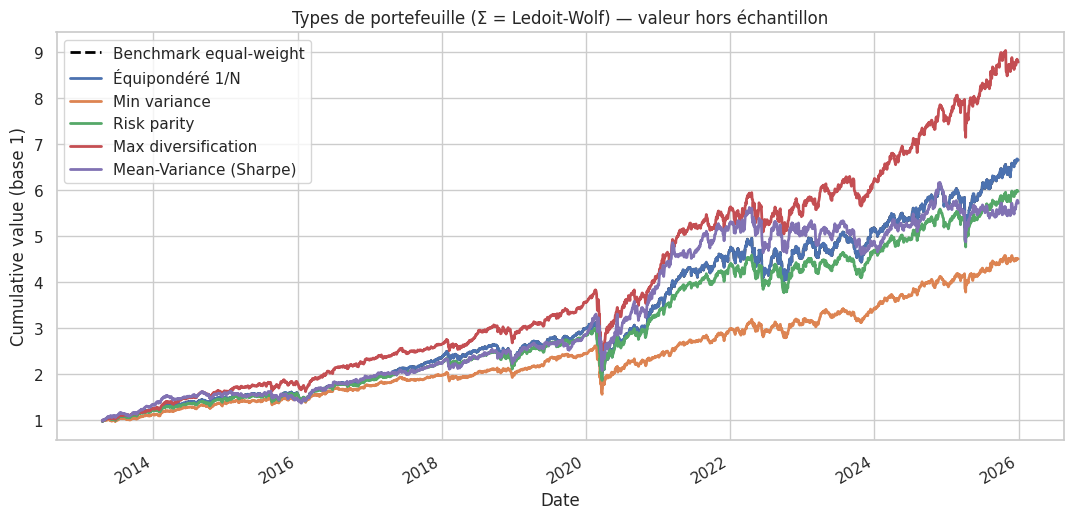

In [19]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_backtest_nav(res_pf, ax=ax)
ax.set_title("Types de portefeuille (Σ = Ledoit-Wolf) — valeur hors échantillon")
plt.show()

## 4. Exemple concret d'allocation de 100 000 € 

On estime/optimise UNIQUEMENT sur le passé (≤ split), on fige les poids, on les applique au futur, et on compare au 1/N (coûts de friction inclus côté backtest).

Estimateur retenu (meilleure log-vraisemblance) : Ledoit-Wolf
Passé : 2949 obs | Futur : 501 obs | Split : 2023-12-31


,poids (%),montant
actif,,
MRK,10.0000,10000.0000
KR,10.0000,10000.0000
KO,10.0000,10000.0000
MCD,10.0000,10000.0000
XEL,9.3700,9370.9300
PSA,8.1500,8148.9500
HSY,7.9600,7958.9500
TECH,5.3500,5346.0200
EA,4.7800,4776.8800


,valeur finale,P&L,rendement total (%),rendement annualisé (%),volatilité (%),Sharpe,max drawdown (%)
Stratégie,127042.1700,27042.1700,27.0400,12.8200,12.0800,0.7300,-8.9200
Équipondéré 1/N,128387.6300,28387.6300,28.3900,13.4200,14.7500,0.6400,-17.6300


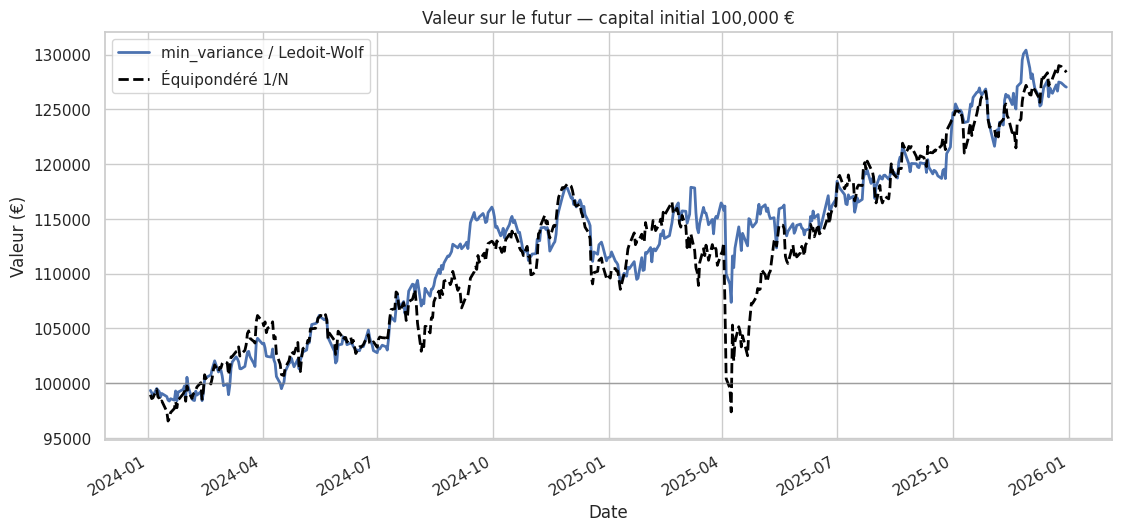

In [20]:
CAPITAL, SPLIT = 100_000.0, "2023-12-31"
best_stat = stat["loglik"].idxmax()          
print(f"Estimateur retenu (meilleure log-vraisemblance) : {best_stat}")
best_cfg = replace(base_mv, cov_estimator=estimators[best_stat])

ex = pl.train_test_split_evaluation(prices, best_cfg, split_date=SPLIT, capital=CAPITAL,
                                    frequency=BT_CFG.frequency, rf_annual=0.04)
print(f"Passé : {ex['n_past']} obs | Futur : {ex['n_future']} obs | Split : {ex['split_date']}")
display(ex["allocation"].head(12))
display(ex["comparison"].round(2))

fig, ax = plt.subplots(figsize=(13, 6))
ex["strategy_nav"].plot(ax=ax, lw=2, label=f"min_variance / {best_stat}")
ex["benchmark_nav"].plot(ax=ax, lw=2, ls="--", color="black", label="Équipondéré 1/N")
ax.axhline(CAPITAL, color="gray", lw=1, alpha=0.6)
ax.set_title(f"Valeur sur le futur — capital initial {CAPITAL:,.0f} €")
ax.set_ylabel("Valeur (€)"); ax.legend(); plt.show()

## Recommandations finales

On agrège les deux axes pour classer les estimateurs. 

In [21]:
ranking = pd.DataFrame({
    "stat: loglik (↑)":      stat["loglik"].rank(ascending=False),
    "stat: vol_err (↓)":     stat["vol_abs_err"].rank(ascending=True),
    "stat: cond. (↓)":       stat["condition_number"].rank(ascending=True),
    "stat: stabilité (↓)":   stat["stabilité"].rank(ascending=True),
    "pf: Sharpe minVar (↑)": m_mv["Sharpe"].rank(ascending=False),
    "pf: vol minVar (↓)":    m_mv["Vol annualized (%)"].rank(ascending=True),
    "pf: turnover (↓)":      pl.weight_stability(res_mv)["turnover moyen"].rank(ascending=True),
})
ranking["RANG MOYEN"] = ranking.mean(axis=1)
display(ranking.sort_values("RANG MOYEN").round(2))

print("\nMeilleur prédictif (loglik)        :", stat["loglik"].idxmax())
print("Meilleur risque (vol minVar OOS)   :", m_mv["Vol annualized (%)"].idxmin())
print("Meilleur conditionnement           :", stat["condition_number"].idxmin())
print("Meilleur Sharpe portefeuille (minVar):", m_mv["Sharpe"].idxmax())
print("Compromis global (rang moyen)      :", ranking["RANG MOYEN"].idxmin())

,stat: loglik (↑),stat: vol_err (↓),stat: cond. (↓),stat: stabilité (↓),pf: Sharpe minVar (↑),pf: vol minVar (↓),pf: turnover (↓),RANG MOYEN
Ledoit-Wolf,1.0000,5.0000,2.0000,2.0000,5.0000,4.0000,2.0000,3.0000
EWMA λ=0.97,6.0000,1.0000,6.0000,7.0000,2.0000,1.0000,6.0000,4.1400
OAS,2.0000,6.0000,3.0000,4.0000,6.0000,5.0000,3.0000,4.1400
Corr. constante,3.0000,7.0000,1.0000,1.0000,8.0000,8.0000,1.0000,4.1400
Rolling-120,5.0000,4.0000,5.0000,5.0000,4.0000,2.0000,5.0000,4.2900
IEWMA,7.0000,3.0000,7.0000,6.0000,3.0000,3.0000,7.0000,5.1400
Empirique,4.0000,8.0000,4.0000,3.0000,7.0000,6.0000,4.0000,5.1400
EWMA λ=0.94,8.0000,2.0000,8.0000,8.0000,1.0000,7.0000,8.0000,6.0000



Meilleur prédictif (loglik)        : Ledoit-Wolf
Meilleur risque (vol minVar OOS)   : EWMA λ=0.97
Meilleur conditionnement           : Corr. constante
Meilleur Sharpe portefeuille (minVar): EWMA λ=0.94
Compromis global (rang moyen)      : Ledoit-Wolf


## 5. Compléments — autocorrélation et analyse spectrale

### a. Autocorrélation (ACF) des rendements et des rendements au carré
L'optimisation de Markowitz traite chaque période comme un tirage i.i.d. : Σ est estimée une fois et supposée stable, sans dépendance temporelle entre les rendements successifs. L'ACF des rendements teste cette hypothèse sur le niveau (les rendements eux-mêmes) ; l'ACF des rendements **au carré** la teste sur la variance (clustering de volatilité, ARCH/GARCH) : une ACF(r) proche de zéro mais une ACF(r²) qui décroît lentement signale que l'hypothèse i.i.d. est défendable sur la moyenne mais pas sur la volatilité — ce qui justifie a posteriori les estimateurs de Σ à pondération temporelle (EWMA, IEWMA) comparés dans ce notebook.

**Portefeuille représentatif** : formulation `min_variance` (optimiseur CVXPY), μ = EWMA (λ=0.9, fixée), Σ = meilleur estimateur par log-vraisemblance parmi les 7 comparés en section 2 (valeur affichée ci-dessous, variable `best_stat`), long-only, poids max 10 %, taux sans risque 4 %/an, capital initial 100 000 €, fenêtre out-of-sample à partir du 2023-12-31 (section 4, variable `ex`). **Cette définition est propre à `covariance.ipynb`** : `return.ipynb` (max_utility / μ=meilleur IC) et `markowitz.ipynb` (Markowitz++) utilisent chacun un portefeuille représentatif différent — ne pas comparer directement une valeur numérique de cette section à celle d'un autre notebook sans remettre ces définitions en regard.

Portefeuille représentatif : min_variance / Σ=Ledoit-Wolf / μ=EWMA(λ=0.9, fixée) / w_max=10% / rf=4%/an / OOS depuis 2023-12-31 / capital initial 100,000€.


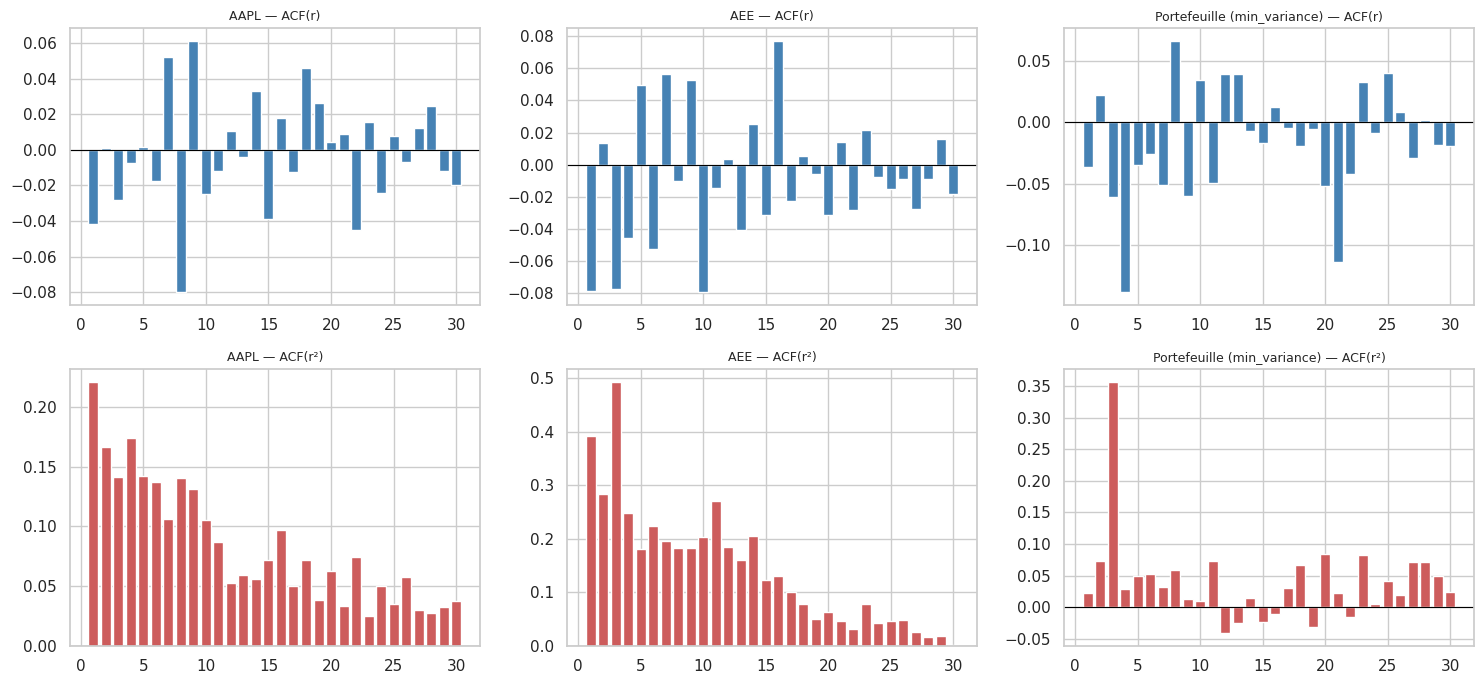

In [22]:
port_ret_cov = ex["strategy_nav"].pct_change().dropna()
print(f"Portefeuille représentatif : min_variance / Σ={best_stat} / μ=EWMA(λ=0.9, fixée) / "
      f"w_max=10% / rf=4%/an / OOS depuis {SPLIT} / capital initial {CAPITAL:,.0f}€.")

assets_sample_cov = list(returns.columns[:2])
series_acf = {c: returns[c].dropna() for c in assets_sample_cov}
series_acf["Portefeuille (min_variance)"] = port_ret_cov

lags_acf = range(1, 31)
fig, axes = plt.subplots(2, len(series_acf), figsize=(15, 7))
for j, (name, s) in enumerate(series_acf.items()):
    acf_r  = [s.autocorr(lag=k) for k in lags_acf]
    acf_r2 = [(s ** 2).autocorr(lag=k) for k in lags_acf]
    axes[0, j].bar(lags_acf, acf_r, color="steelblue"); axes[0, j].axhline(0, color="black", lw=0.8)
    axes[0, j].set_title(f"{name} — ACF(r)", fontsize=9)
    axes[1, j].bar(lags_acf, acf_r2, color="indianred"); axes[1, j].axhline(0, color="black", lw=0.8)
    axes[1, j].set_title(f"{name} — ACF(r²)", fontsize=9)
plt.tight_layout(); plt.show()

### b. Analyse spectrale (densité spectrale de puissance)
La PSD (estimée par la méthode de Welch) décompose la variance des rendements par fréquence. L'absence de pic dominant indique qu'aucune cyclicité régulière n'est décelable à l'échelle journalière — cohérent avec l'ACF(r) plate observée ci-dessus. Illustré sur le seul portefeuille représentatif (pas sur tout l'univers, l'intérêt est qualitatif).

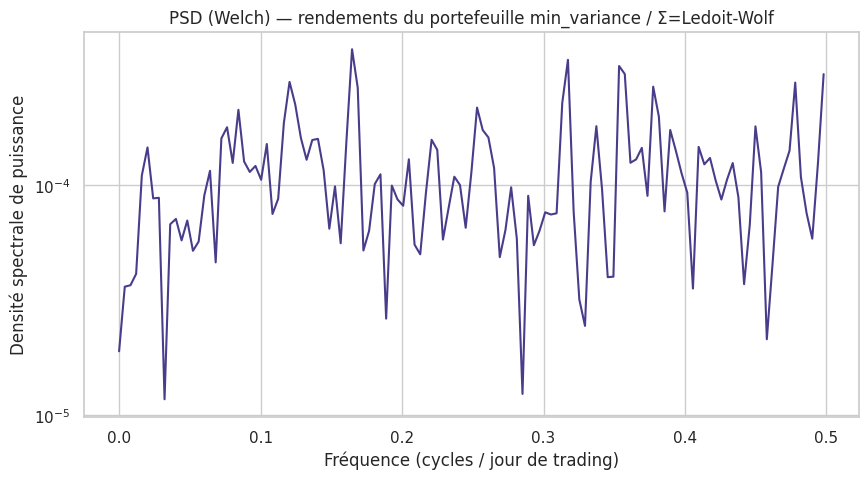

In [23]:
from scipy.signal import welch

freqs, psd = welch(port_ret_cov.values, fs=1.0, nperseg=min(256, len(port_ret_cov) // 2))
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(freqs, psd, color="darkslateblue")
ax.set_xlabel("Fréquence (cycles / jour de trading)"); ax.set_ylabel("Densité spectrale de puissance")
ax.set_title(f"PSD (Welch) — rendements du portefeuille min_variance / Σ={best_stat}")
plt.show()

##  Journalisation du run (`results/`)




In [24]:
from portfolio_lab.reporting import RunReport

rep = RunReport("covariance", results_dir="results")
rep.capture(
    prices=prices, selector=SELECTOR,
    requested_n=getattr(SELECTOR, "n_total", getattr(SELECTOR, "n", None)),
    period=(START, END), bt_cfg=BT_CFG, base_config=base_mv, use_synthetic=USE_SYNTHETIC,
    cov_estimators=estimators, mean_estimators={"μ": MEAN_EST},
)
ns = globals()
rep.add_if(ns, "stat",        "Qualité statistique de Σ (OOS)")
rep.add_if(ns, "regime_rows", "Régime crise / hors-crise")
rep.add_if(ns, "res_mv",      "Portefeuille min_variance — on varie Σ", columns=cols_perf)
rep.add_if(ns, "res_ms",      "Portefeuille max_sharpe — on varie Σ")
print("Rapport écrit :", rep.save())   # rep.save(fmt="both") pour tenter un PDF (pandoc)


Rapport écrit : results/covariance__2026-06-21_151953.md
